# Fake Review Detection & Trust Analytics
## 🚀 Stage 1: Data Acquisition & Advanced Business Intelligence

**Project Manager:** Balaji Sakthivel  
**Phase:** Stage 1  
**Objective:** Load data, perform EDA, and establish the BI foundation for fraud detection.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import os

# Premium Design Config
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'font.size': 12
})

import warnings
warnings.filterwarnings('ignore')

### 1. Data Acquisition
Ingesting the primary dataset and performing schema validation.

In [2]:
data_path = "../data/fake_review_dataset.csv"
df = pd.read_csv(data_path)

print(f"✅ Dataset Ingested: {df.shape[0]} reviews, {df.shape[1]} features.")
display(df.head())

✅ Dataset Ingested: 70000 reviews, 10 features.


,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,developer_reply_date,app_name
0,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,Sean Harris,"always happy with their service and goods,just...",5,0,32.4.0.100,2026-03-11 18:25:22,NaN,NaN,Amazon Shopping
1,7a6f39b1-5534-4eed-8100-1cdbedc5ea1e,Finn Fiechtner,pros and cons. 3 star review dead center. cons...,3,0,NaN,2026-03-11 18:15:01,NaN,NaN,Amazon Shopping
2,967d3ed1-6855-493d-8816-d7434a22180c,Bassam Yousre,the worst delivery service ever always not on ...,1,0,32.5.0.100,2026-03-11 18:08:16,NaN,NaN,Amazon Shopping
3,9767efd5-66d8-4dc8-a86f-2c2a26bd0ee4,SO SUPO,happy,4,0,32.5.0.100,2026-03-11 17:57:29,NaN,NaN,Amazon Shopping
4,26cf286d-c77c-4c64-ba92-dbb119a510fe,Steve Day,Says my phone is not compatible with tap to pa...,1,0,32.5.0.100,2026-03-11 16:45:46,NaN,NaN,Amazon Shopping


### 2. General Exploratory Data Analysis (EDA)
Understanding the data structure and statistical distribution.

In [3]:
print("--- Dataset Information ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe(include='all'))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   review_id             70000 non-null  object
 1   user_name             69999 non-null  object
 2   review_text           70000 non-null  object
 3   rating                70000 non-null  int64 
 4   helpful_votes         70000 non-null  int64 
 5   app_version           59163 non-null  object
 6   review_date           70000 non-null  object
 7   developer_reply       28908 non-null  object
 8   developer_reply_date  28908 non-null  object
 9   app_name              70000 non-null  object
dtypes: int64(2), object(8)
memory usage: 5.3+ MB

--- Descriptive Statistics ---


,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,developer_reply_date,app_name
count,70000,69999,70000,70000.000000,70000.000000,59163,70000,28908,28908,70000
unique,70000,64953,42662,NaN,NaN,721,68886,3693,28603,7
top,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,A Google user,good,NaN,NaN,4.2602.11,2026-03-06 22:48:12,"Hi Flipkart User, Thank you so much for your f...",2025-10-25 22:07:30,Amazon Shopping
freq,1,94,7109,NaN,NaN,6913,3,7994,4,10000
mean,NaN,NaN,NaN,3.748357,0.913529,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.723051,18.075051,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,5.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,5.000000,0.000000,NaN,NaN,NaN,NaN,NaN


### 3. Missing Values Identification
Identifying data gaps that impact trust analytics.

Missing Values per Column:
user_name                   1
app_version             10837
developer_reply         41092
developer_reply_date    41092
dtype: int64


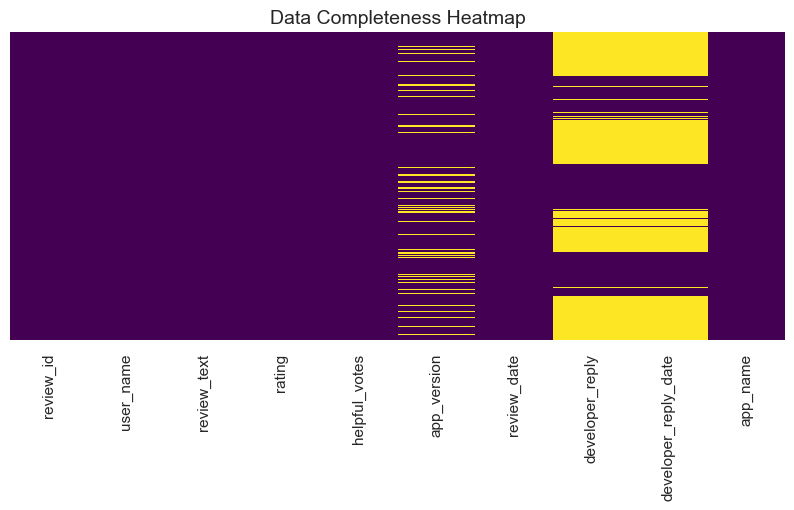

In [4]:
missing_data = df.isnull().sum()
print("Missing Values per Column:")
print(missing_data[missing_data > 0])

# Visualization of data completeness
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Data Completeness Heatmap')
plt.show()

### 4. Rating Distribution & Market Polarization
Analyzing user sentiment trends and calculating the Skewness factor.

Rating Skewness: -0.83 (Negative skew suggests high-rating dominance)


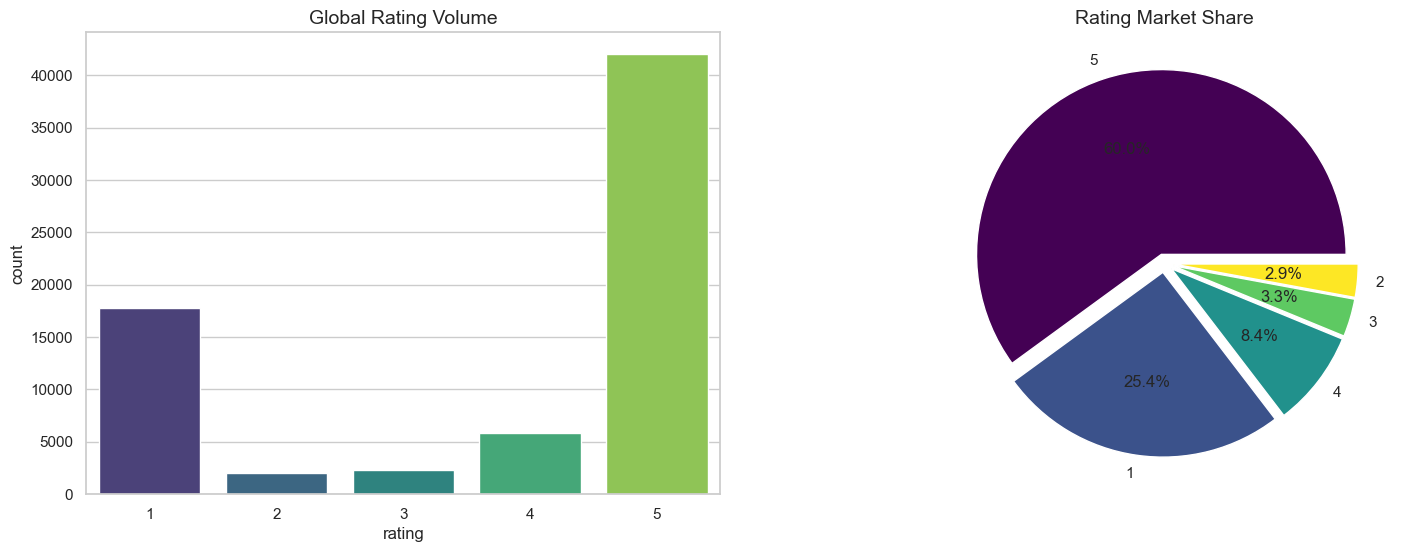

In [5]:
r_skew = skew(df['rating'])
print(f"Rating Skewness: {r_skew:.2f} (Negative skew suggests high-rating dominance)")

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x='rating', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Global Rating Volume')

df['rating'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], cmap='viridis', explode=[0.05]*df['rating'].nunique())
ax[1].set_title('Rating Market Share')
ax[1].set_ylabel('')
plt.show()

### 5. App-wise Competitive Analysis
Comparing performance and review volume across different applications.

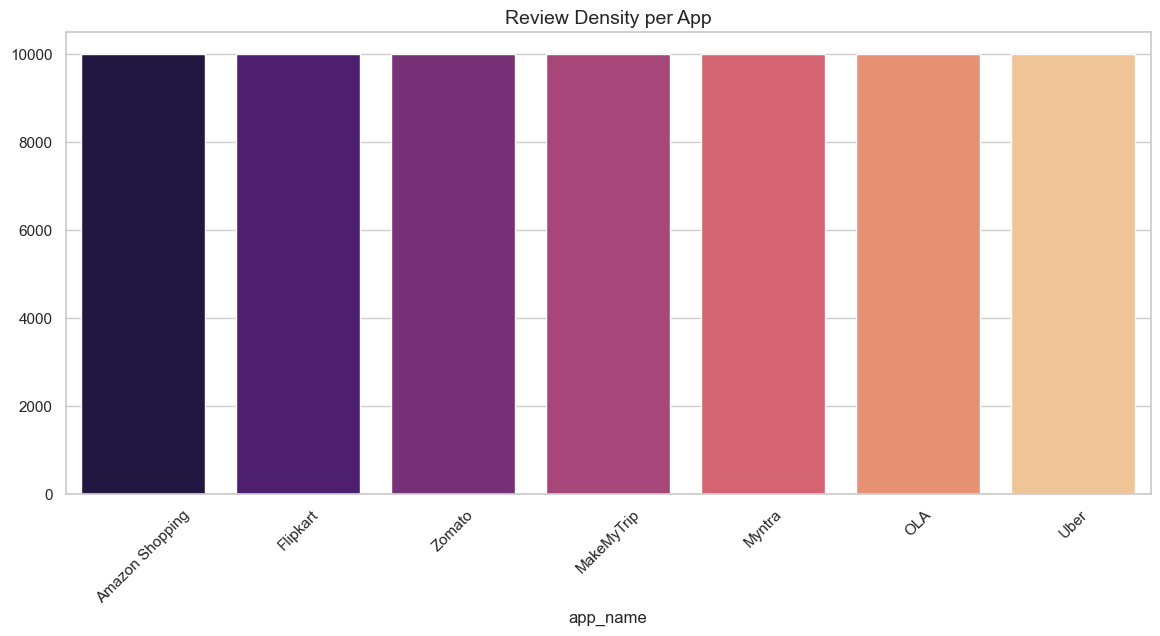

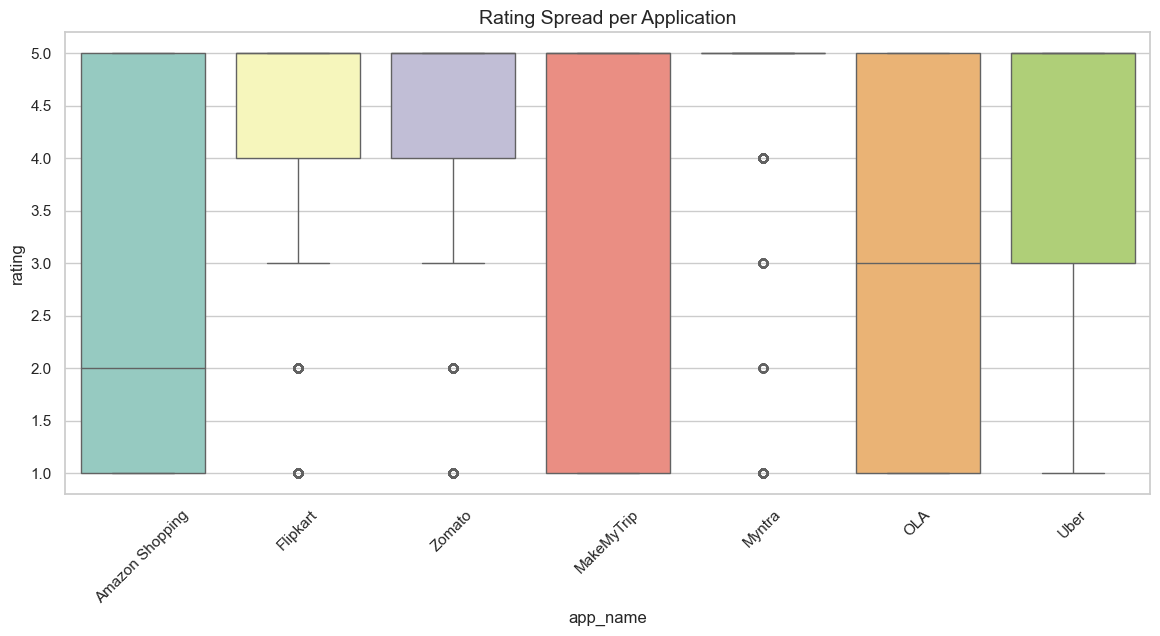

In [6]:
plt.figure(figsize=(14, 6))
app_counts = df['app_name'].value_counts()
sns.barplot(x=app_counts.index, y=app_counts.values, palette='magma')
plt.title('Review Density per App')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(x='app_name', y='rating', data=df, palette='Set3')
plt.title('Rating Spread per Application')
plt.xticks(rotation=45)
plt.show()

### 6. Proactive Optimization: Temporal & Behavioral Signals
Adding engineered features to jumpstart the Fake Detection stage.

In [7]:
# Signal 1: Review Length (Bot Detection Prep)
df['review_length'] = df['review_text'].astype(str).apply(len)

# Signal 2: Temporal Mapping
df['review_date'] = pd.to_datetime(df['review_date'])
df['hour'] = df['review_date'].dt.hour

print("Engineered 'review_length' and 'hour' signals for fraud detection.")
display(df[['review_text', 'review_length', 'hour']].head())

Engineered 'review_length' and 'hour' signals for fraud detection.


,review_text,review_length,hour
0,"always happy with their service and goods,just...",97,18
1,pros and cons. 3 star review dead center. cons...,484,18
2,the worst delivery service ever always not on ...,141,18
3,happy,5,17
4,Says my phone is not compatible with tap to pa...,278,16


### 7. Handover Export
Saving the optimized dataset for the next stage: **Data Cleaning (Hasini)**.

In [9]:
export_file = "../data/stage1_loaded_data.csv"
df.to_csv(export_file, index=False)
print(f"🚀 Stage 1 COMPLETE. Handover file ready: {export_file}")

🚀 Stage 1 COMPLETE. Handover file ready: ../data/stage1_loaded_data.csv
